## Imports And Library Loading

In [39]:
import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import timm
from torchvision import transforms
import tqdm
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve, average_precision_score
)
from collections import defaultdict, OrderedDict
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime
import json


## Dataset Class And Validation

In [40]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes
    

In [41]:
# Dataset Directory Assignment
train_image_dataset = ImageDataset(data_dir=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\train")
test_image_dataset = ImageDataset(data_dir=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\test")
val_image_dataset = ImageDataset(data_dir=r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\val")

In [43]:
# Print the number of images in each dataset
len(train_image_dataset), len(test_image_dataset), len(val_image_dataset) 

(25696, 3213, 3212)

0


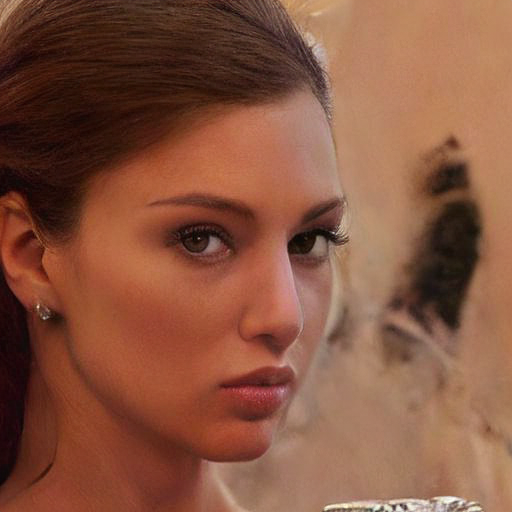

In [44]:
# Test Itration
image, label = test_image_dataset[300]
print(label)
image

In [45]:
# Dataset Class Index Validation

train_data_dir = train_image_dataset.data.root
val_data_dir = val_image_dataset.data.root
test_data_dir = test_image_dataset.data.root

target_to_class_train = {v : k for k, v in ImageFolder(train_data_dir).class_to_idx.items()}
print(target_to_class_train)
target_to_class_val = {v : k for k, v in ImageFolder(val_data_dir).class_to_idx.items()}
print(target_to_class_val)
target_to_class_test = {v : k for k, v in ImageFolder(test_data_dir).class_to_idx.items()}
print(target_to_class_test)


print(train_data_dir)

{0: 'fake', 1: 'real'}
{0: 'fake', 1: 'real'}
{0: 'fake', 1: 'real'}
C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\dataset\train


In [46]:
# Valuation Dataset Shape and Label

image, label = val_image_dataset[100]
print("Image shape:", image.size)
print("Label:", label)
print("Dataset length:", len(val_image_dataset))

Image shape: (256, 256)
Label: 0
Dataset length: 3212


## Dataset Transformation and Augmentation

In [47]:
import torchvision.transforms as transforms
import torch # Needed for torch.rand() for dynamic sharpness

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    # 1. Resizing (usually done first)
    transforms.Resize((256, 256)),

    # 2. Geometric Transformations (operate on PIL Images)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomApply([transforms.ElasticTransform(alpha=250.0, sigma=15.0)], p=0.2),
    # Choose one RandomPerspective; I'll use the p=0.5 as it was first and not commented out
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),

    # 3. Photometric / Color Transformations (operate on PIL Images)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0)), # Consider adjusting params as discussed earlier

    # Correct way to apply random sharpness/blur
    transforms.RandomApply([
        transforms.RandomAdjustSharpness(sharpness_factor=torch.rand(1).item() * 1.5 + 0.25)
        # This will randomly pick a sharpness factor between 0.25 (blurrier) and 1.75 (sharper)
    ], p=0.2), # Apply this random sharpness/blur with a 20% probability


    # 4. Conversion to Tensor (PIL Image -> Tensor)
    transforms.ToTensor(),

    # 5. Normalization (operate on Tensor)
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),

    # 6. Tensor-based Augmentations (operate on Tensor, should come after ToTensor and Normalize)
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
])

# Don't forget your validation/test transform (no random augmentations)
val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


train_dataset = ImageDataset(train_data_dir, train_transform)
val_dataset = ImageDataset(val_data_dir, val_test_transform)
test_dataset = ImageDataset(test_data_dir, val_test_transform)

In [48]:
# Tranformation Check
train_dataset[300]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

In [49]:
# Iterate over the transformed dataset
for image, label in train_dataset:
    break

In [50]:
image.size()

torch.Size([3, 256, 256])

## Dataloader

In [51]:
# train_detaset is the tensor of out train
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [52]:
# Validation of dataloader
image, label = train_dataset[100]
print("Image size:", image.size)

Image size: <built-in method size of Tensor object at 0x000001B3F21ACE50>


In [53]:
image, label = val_dataset[100]
print("Image shape:", image.shape)  # Use .shape for tensor

Image shape: torch.Size([3, 256, 256])


In [54]:
# Test iterate over the train dataset
for images, labels in train_dataset:
    break

In [55]:
image.size(), label

(torch.Size([3, 256, 256]), 0)

## Models

Deep Learning Models

### EfficientnetB0

In [17]:
# Basic efficientnet_b0 Model Class.
class EfficientnetB0_Builder(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4, use_pretrained=True):
        super(EfficientnetB0_Builder, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=use_pretrained)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1]) 

        enet_out_size = 1280
        # Make a classifier
        self.classifier = nn.Sequential(
            nn.Flatten(), # Flatten the output from the feature extractor from (batch, 1280, 1, 1) to (batch, 1280)
            nn.Dropout(dropout_rate),  # Dropout layer for regularization
            nn.Linear(enet_out_size, num_classes) # Final linear layer for classification

        )
            # Information about pre-trained weights and potential freezing
        if use_pretrained:
            print("Using pre-trained EfficientnetB0 weights.")
            # Optional: If your dataset is small, you might consider freezing
            # the feature backbone and only training the new classifier head.
            # Uncomment the following lines to do so:
            # for param in self.features.parameters():
            #     param.requires_grad = False
            # print("Frozen MobileNetV3_Large feature backbone. Only classifier layers are trainable.")
        else:
            print("Training EfficientnetB0 from scratch.")

    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        return output

In [18]:
# Print the model structure
model = EfficientnetB0_Builder(num_classes=2)
print(model)

Using pre-trained EfficientnetB0 weights.
EfficientnetB0_Builder(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
         

### Resnet 50

In [19]:
class Resnet50_Builder(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4, use_pretrained=True):
        """
        Initializes a ResNet-50 model structured like the EfficientNetB0 DeepFakeClassifier.

        Args:
            num_classes (int): The number of output classes (default: 2 for real/deepfake).
            dropout_rate (float): Dropout probability for the classification head.
            use_pretrained (bool): If True, loads a ResNet-50 model pre-trained on ImageNet.
        """
        super(Resnet50_Builder, self).__init__()

        # 1. Define the base model (ResNet-50)
        self.base_model = timm.create_model('resnet50', pretrained=use_pretrained)

        # 2. Extract the feature backbone (everything before the final 'fc' layer)
        # For ResNet-50, the features typically include layers up to avgpool.
        # The final 'fc' layer is what we'll replace with our custom classifier.
        # A common way to get the features is to take all children except the last one.
        # Alternatively, if you want to include the avgpool in the classifier's Flatten,
        # you'd take children up to -2. Here, we'll let the model's avgpool handle it,
        # and then Flatten the output of the avgpool.
        
        # Access all modules of ResNet-50 up to (but not including) the 'fc' layer
        # This includes conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool
        self.features = nn.Sequential(*list(self.base_model.children())[:-1]) 

        # Get the output size of the feature extractor.
        # For ResNet-50, after the `avgpool` layer, the output is a 2048-dimensional vector.
        # This is equivalent to `enet_out_size` in your EfficientNet example.
        enet_out_size = 2048 # This will be 2048 for ResNet-50

        # 3. Create the classifier head, including Flatten, Dropout, and Linear layer
        self.classifier = nn.Sequential(
            nn.Flatten(),                     # Flattens the output of the features (e.g., (batch, 2048, 1, 1) to (batch, 2048))
            nn.Dropout(dropout_rate),         # Dropout layer for regularization
            nn.Linear(enet_out_size, num_classes) # Final linear layer for classification
        )

        # Important: If using pretrained, you might want to freeze early layers
        # or fine-tune specific blocks based on your dataset size and task.
        # By default, all parameters are trainable unless explicitly frozen.
        if use_pretrained:
            print("Using pre-trained ResNet-50 weights.")
            # If you want to freeze the features and only train the classifier:
            # for param in self.features.parameters():
            #     param.requires_grad = False
            # print("Frozen ResNet-50 feature backbone. Only classifier layers are trainable.")
        else:
            print("Training ResNet-50 from scratch.")


    def forward(self, x):
        """
        Forward pass through the model.

        Args:
            x (torch.Tensor): Input tensor (image batch).

        Returns:
            torch.Tensor: Output logits from the model.
        """
        x = self.features(x)   # Pass through the feature extraction backbone
        output = self.classifier(x) # Pass through the custom classification head
        return output

In [20]:
# Print the model structure
model = Resnet50_Builder(num_classes=2)
print(model)

Using pre-trained ResNet-50 weights.
Resnet50_Builder(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act2): ReLU(inplace=True)
        (aa): Identity()
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False

### DenseNet-121

In [56]:
class Densenet121_Builder(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4, use_pretrained=True):
        """
        Initializes a DenseNet-121 model structured like the EfficientNetB0 DeepFakeClassifier.

        Args:
            num_classes (int): The number of output classes (default: 2 for real/deepfake).
            dropout_rate (float): Dropout probability for the classification head.
            use_pretrained (bool): If True, loads a DenseNet-121 model pre-trained on ImageNet.
        """
        super(Densenet121_Builder, self).__init__()

        # 1. Define the base model (DenseNet-121)
        self.base_model = timm.create_model('densenet121', pretrained=use_pretrained)

        # 2. Extract the feature backbone (everything before the final classifier layer)
        # For DenseNet-121, the feature extractor is contained in 'features' attribute,
        # which includes all conv layers, dense blocks, and transition layers,
        # ending with a global average pooling implicitly by the last BatchNorm layer.
        # self.features = self.base_model.features # This is already a nn.Sequential module
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        # 3. Determine the output size of the feature extractor.
        # For DenseNet-121, after the 'features' module and its final BatchNorm,
        # the output is 1024 channels, which then passes through an activation
        # before the final classifier. So, the output size is 1024.
        enet_out_size = 1024 # This will be 1024 for DenseNet-121

        # 4. Create the classifier head, including Flatten, Dropout, and Linear layer
        self.classifier = nn.Sequential(
            nn.ReLU(inplace=True),             # DenseNet's features typically end before the final ReLU
            # nn.AdaptiveAvgPool2d((1, 1)),      # Ensure consistent (1,1) spatial dimensions if not already handled
            nn.Flatten(),                      # Flattens the output (e.g., (batch, 1024, 1, 1) to (batch, 1024))
            nn.Dropout(dropout_rate),          # Dropout layer for regularization
            nn.Linear(enet_out_size, num_classes) # Final linear layer for classification
        )

        # Important: If using pretrained, you might want to freeze early layers
        # or fine-tune specific blocks based on your dataset size and task.
        # By default, all parameters are trainable unless explicitly frozen.
        if use_pretrained:
            print("Using pre-trained DenseNet-121 weights.")
            # If you want to freeze the features and only train the classifier:
            # for param in self.features.parameters():
            #     param.requires_grad = False
            # print("Frozen DenseNet-121 feature backbone. Only classifier layers are trainable.")
        else:
            print("Training DenseNet-121 from scratch.")


    def forward(self, x):
        """
        Forward pass through the model.

        Args:
            x (torch.Tensor): Input tensor (image batch).

        Returns:
            torch.Tensor: Output logits from the model.
        """
        x = self.features(x)     # Pass through the feature extraction backbone
        output = self.classifier(x) # Pass through the custom classification head
        return output

In [57]:
# Print the model structure
model = Densenet121_Builder(num_classes=2)
print(model)

Using pre-trained DenseNet-121 weights.
Densenet121_Builder(
  (base_model): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNormAct2d(
        64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): ReLU(inplace=True)
      )
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): DenseBlock(
        (denselayer1): DenseLayer(
          (norm1): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNormAct2d(
            128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)

### MobilenetV3

In [23]:
class MobilenetV3_Builder(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4, use_pretrained=True):
        """
        Initializes a MobileNetV3_Large model structured like the EfficientNetB0 DeepFakeClassifier.

        Args:
            num_classes (int): The number of output classes (default: 2 for real/deepfake).
            dropout_rate (float): Dropout probability for the classification head.
            use_pretrained (bool): If True, loads a MobileNetV3_Large model pre-trained on ImageNet.
        """
        super(MobilenetV3_Builder, self).__init__()

        # 1. Define the base model (MobileNetV3_Large)
        # We'll use MobileNetV3_Large as it generally offers better performance
        # compared to MobileNetV3_Small for classification tasks.
        self.base_model = timm.create_model('mobilenetv3_large_100', pretrained=use_pretrained)

        # 2. Extract the feature backbone
        # For MobileNetV3 models, the feature extractor is directly available
        # via the 'features' attribute of the base model. This includes all
        # the inverted residual blocks and convolutional layers before the
        # final classification part.
        # self.features = self.base_model.features
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        # 3. Determine the output size of the feature extractor.
        # For MobileNetV3_Large, after the `features` module, the next part
        # in the original model is typically a 1x1 convolution (often `_pre_last_layer`)
        # which outputs 960 channels before the final pooling and classification.
        # We can extract this size from the first layer of the original classifier.
        enet_out_size = 1280 # This will be 960 for MobileNetV3_Large

        # 4. Create the custom classifier head.
        # MobileNetV3's `features` output a feature map (e.g., 960x7x7).
        # We need to apply global average pooling and flatten before the linear layer.
        self.classifier = nn.Sequential(
            # nn.AdaptiveAvgPool2d((1, 1)),     # Global average pooling to reduce spatial dims to 1x1
            nn.Flatten(),                     # Flattens the output (e.g., (batch, 960, 1, 1) to (batch, 960))
            nn.Dropout(p=dropout_rate),       # Dropout layer for regularization
            nn.Linear(enet_out_size, num_classes) # Final linear layer for classification
        )

        # Information about pre-trained weights and potential freezing
        if use_pretrained:
            print("Using pre-trained MobileNetV3_Large weights.")
            # Optional: If your dataset is small, you might consider freezing
            # the feature backbone and only training the new classifier head.
            # Uncomment the following lines to do so:
            # for param in self.features.parameters():
            #     param.requires_grad = False
            # print("Frozen MobileNetV3_Large feature backbone. Only classifier layers are trainable.")
        else:
            print("Training MobileNetV3_Large from scratch.")


    def forward(self, x):
        """
        Forward pass through the model.

        Args:
            x (torch.Tensor): Input tensor (image batch).

        Returns:
            torch.Tensor: Output logits from the model.
        """
        x = self.features(x)       # Pass through the MobileNetV3 feature extractor
        output = self.classifier(x) # Pass through the custom classification head
        return output

In [24]:
# Print the model structure
model = MobilenetV3_Builder(num_classes=2)
print(model)

Using pre-trained MobileNetV3_Large weights.
MobilenetV3_Builder(
  (base_model): MobileNetV3(
    (conv_stem): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): Hardswish()
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (bn1): BatchNormAct2d(
            16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU(inplace=True)
          )
          (aa): Identity()
          (se): Identity()
          (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNormAct2d(
            16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop

## Configaration Class

In [58]:
import torch
import tqdm
from collections import defaultdict
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, average_precision_score
from torch.utils.tensorboard import SummaryWriter
import os
import json
import datetime # Added this import for datetime.datetime.now()

# Configuration class to encapsulate all training parameters and paths
class Config:
    def __init__(self,
                 model,
                 optimizer,
                 criterion,
                 val_data_dir,
                 class_names,
                 num_epochs,
                 device,
                 scheduler,
                 test_data_dir,
                 train_data_dir,
                 train_losses,
                 val_losses,
                 train_accuracies,
                 val_accuracies,
                 save_top_k=3, # Default value, can be overridden
                 img_size=256, # Default image size, can be overridden
                 # Removed: early_stop, early_stop_patience, early_stop_min_delta
                ):
        self.model_name = model.__class__.__name__
        # Core training components
        self.img_size = img_size
        self.optimizer_type = optimizer.__class__.__name__,
        self.criterion_type = criterion.__class__.__name__
        self.train_dataset = train_data_dir
        self.test_dataset = test_data_dir
        self.val_dataset = val_data_dir
        self.data_class_names = class_names # Assuming class names are the same across datasets
        self.num_epochs = num_epochs
        self.device_name = device.type if isinstance(device, torch.device) else device
        self.scheduler_name = scheduler.__class__.__name__

        # Data Augmentation and normalization
        self.augment = True

        # Removed: Early stopping configuration (self.early_stop, self.patience_counter, self.early_stop_min_delta)

        # Training and validation metrics (lists to be populated during training)
        self.train_losses = train_losses
        self.val_losses = val_losses
        self.train_accuracies = train_accuracies
        self.val_accuracies = val_accuracies

        # Experiment tracking
        self.timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

        # Paths and directories (dynamically generated)
        model_name_lower = model.__class__.__name__.lower()
        self.exp_name = f"{model_name_lower}_{self.timestamp}"
        self.exp_dir = os.path.join("experiments", self.exp_name)
        self.model_path = os.path.join(self.exp_dir, "best_model.pth")
        self.last_model_path = os.path.join(self.exp_dir, "last_model.pth")
        self.log_dir = os.path.join(self.exp_dir, "logs")
        
        self.save_top_k = save_top_k # Number of best models to save
        self.history_path = os.path.join(self.exp_dir, "history.json")

        # Create experiment directories if they don't exist
        os.makedirs(self.log_dir, exist_ok=True)
        print(f"Experiment directory created: {self.exp_dir}")
        print(f"Model will be saved to: {self.model_path}")
        print(f"Last model will be saved to: {self.last_model_path}")
        print(f"TensorBoard logs will be saved to: {self.log_dir}")

    def save(self):
        """Save configuration to experiment directory"""
        config_dict = {k:v for k,v in vars(self).items() if not k.startswith('__') and k != 'class_names'}
        with open(os.path.join(self.exp_dir, "config.json"), 'w') as f:
            json.dump(config_dict, f, indent=2)

## Tesorboard Plots Function

In [32]:
# Function to plot training history and save the plots
import matplotlib.pyplot as plt

def plot_training_history(history, cfg):
    """Plot training metrics and save to experiment directory"""
    plt.figure(figsize=(18, 12))
    
    # Plot loss
    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot accuracy
    plt.subplot(2, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Validation')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot AUC
    plt.subplot(2, 2, 3)
    plt.plot(history['val_auc'], label='Validation')
    plt.title('Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    
    # Plot learning rate
    plt.subplot(2, 2, 4)
    plt.plot(history['lr'])
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('LR')
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.exp_dir, "training_metrics.png"))
    plt.close()

def plot_evaluation_report(model, loader, cfg, phase="val"):
    """Generate comprehensive evaluation report with visualizations"""
    
    # Ensure cfg.class_names is available and correctly set (e.g., ['fake', 'real'])
    # This is handled by your Config class if you set it up with target_to_class_train
    if not hasattr(cfg, 'class_names') or not cfg.class_names:
        print("Warning: cfg.class_names is not set. Using default ['Class 0', 'Class 1'] for report labels.")
        cfg.class_names = ['Class 0', 'Class 1'] # Fallback for plotting

    # Use next(model.parameters()).device to get the device if model is on CUDA/CPU
    # If the model is not yet on a device, you might need to pass the device explicitly from outside.
    # For robust evaluation, ensure the model is on the correct device when evaluate_model is called.
    device_for_eval = next(model.parameters()).device 
    
    metrics, y_true, y_scores, y_pred = evaluate_model(model, loader, device=device_for_eval)
    
    report = {
        'metrics': metrics,
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
        'classification_report': classification_report(
            y_true, y_pred, target_names=cfg.class_names, output_dict=True
        )
    }
    
    # Ensure experiment directory exists before saving
    os.makedirs(cfg.exp_dir, exist_ok=True) 

    # Save report JSON
    report_path = os.path.join(cfg.exp_dir, f"{phase}_report.json")
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=2)
    print(f"Report for {phase.capitalize()} saved to: {report_path}")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    # Convert confusion matrix to a numpy array if it's a list of lists for sns.heatmap
    cm_data = report['confusion_matrix'] # It's already a list of lists from .tolist()
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', 
                xticklabels=cfg.class_names, yticklabels=cfg.class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f"Confusion Matrix ({phase.capitalize()})")
    plt.savefig(os.path.join(cfg.exp_dir, f"{phase}_confusion_matrix.png"))
    plt.close()
    print(f"Confusion Matrix for {phase.capitalize()} saved to: {os.path.join(cfg.exp_dir, f'{phase}_confusion_matrix.png')}")
    
    # Plot PR curve
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"AP = {metrics['ap']:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve ({phase.capitalize()})")
    plt.legend()
    plt.savefig(os.path.join(cfg.exp_dir, f"{phase}_pr_curve.png"))
    plt.close()
    print(f"Precision-Recall Curve for {phase.capitalize()} saved to: {os.path.join(cfg.exp_dir, f'{phase}_pr_curve.png')}")

## Training Loop

In [63]:
def training_model(num_epochs, model, train_loader, val_loader, optimizer, criterion, scheduler, device, cfg):
    """
    Trains and validates a deep learning model.

    Args:
        num_epochs (int): The total number of epochs for training.
        model (torch.nn.Module): The neural network model to train.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training dataset.
        val_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        optimizer (torch.optim.Optimizer): The optimizer used for updating model weights.
        criterion (torch.nn.Module): The loss function.
        scheduler (torch.optim.lr_scheduler._LRScheduler): Learning rate scheduler.
        device (torch.device): The device (CPU or GPU) to run the training on.
        cfg: Configuration object containing parameters like log_dir, etc.
    """

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    history = defaultdict(list)
    # Kept best_metrics for saving the best model based on AUC throughout full training
    best_metrics = {'auc': 0.0, 'epoch': 0, 'val_loss': float('inf')} 
    # Removed: early_stop_counter = 0
    writer = SummaryWriter(cfg.log_dir)

    # --- Training and Validation Loop ---
    for epoch in range(num_epochs):
        print(f"Starting epoch {epoch+1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct_train_predictions = 0
        total_train_samples = 0
        
        for images, labels in tqdm.tqdm(train_loader, desc=f'Training Epoch {epoch+1}/{num_epochs}'):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
            preds = outputs.argmax(dim=1)
            correct_train_predictions += (preds == labels).sum().item()
            total_train_samples += labels.size(0)
            
        train_loss = running_loss / total_train_samples
        train_losses.append(train_loss)
        train_acc = correct_train_predictions / total_train_samples
        train_accuracies.append(train_acc)
        
        # Validation phase
        model.eval()
        running_val_loss = 0.0
        correct_val_predictions = 0
        total_val_samples = 0
        all_labels_val = []
        all_preds_val = []
        all_outputs_softmax_val = []
        
        with torch.no_grad():
            for images, labels in tqdm.tqdm(val_loader, desc=f'Validation Epoch {epoch+1}/{num_epochs}'):
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
                
                preds = outputs.argmax(dim=1)
                
                # Accumulate for overall metrics
                all_labels_val.extend(labels.cpu().numpy())
                all_preds_val.extend(preds.cpu().numpy())
                all_outputs_softmax_val.extend(outputs.softmax(dim=1).cpu().numpy())
                
                correct_val_predictions += (preds == labels).sum().item()
                total_val_samples += labels.size(0)
                
        val_loss = running_val_loss / total_val_samples
        val_losses.append(val_loss)
        val_acc = correct_val_predictions / total_val_samples
        val_accuracies.append(val_acc)

        # Calculate ALL validation metrics once after the loop
        if total_val_samples > 0:
            # Assuming binary classification for output[1]
            # Adjust if you have multi-class and need one-vs-rest or different aggregation
            val_auc = roc_auc_score(all_labels_val, [output[1] for output in all_outputs_softmax_val])
            val_f1 = f1_score(all_labels_val, all_preds_val, average='weighted')
            val_precision = precision_score(all_labels_val, all_preds_val, average='weighted', zero_division=0)
            val_recall = recall_score(all_labels_val, all_preds_val, average='weighted', zero_division=0)
            val_ap = average_precision_score(all_labels_val, [output[1] for output in all_outputs_softmax_val])
        else:
            val_auc, val_f1, val_precision, val_recall, val_ap = 0.0, 0.0, 0.0, 0.0, 0.0

        print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}, train_accuracy: {train_acc:.4f}, val_accuracy: {val_acc:.4f}",
              f"val_auc: {val_auc:.4f}, val_f1: {val_f1:.4f}, val_precision: {val_precision:.4f}, val_recall: {val_recall:.4f}, val_ap: {val_ap:.4f}")

        # --- LEARNING RATE SCHEDULER STEP ---
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr:.6f}")
        # ------------------------------------

        # --- Logging to History and TensorBoard ---
        val_metrics_current_epoch = {
            'loss': val_loss,
            'accuracy': val_acc,
            'auc': val_auc,
            'f1': val_f1,
            'precision': val_precision,
            'recall': val_recall,
            'ap': val_ap
        }

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics_current_epoch['loss'])
        history['val_acc'].append(val_metrics_current_epoch['accuracy'])
        history['val_auc'].append(val_metrics_current_epoch['auc'])
        history['val_f1'].append(val_metrics_current_epoch['f1'])
        history['val_precision'].append(val_metrics_current_epoch['precision'])
        history['val_recall'].append(val_metrics_current_epoch['recall'])
        history['val_ap'].append(val_metrics_current_epoch['ap'])
        history['lr'].append(current_lr)

        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_metrics_current_epoch['loss'], epoch)
        writer.add_scalar('Accuracy/train', train_acc, epoch)
        writer.add_scalar('Accuracy/val', val_metrics_current_epoch['accuracy'], epoch)
        writer.add_scalar('AUC/val', val_metrics_current_epoch['auc'], epoch)
        writer.add_scalar('F1/val', val_metrics_current_epoch['f1'], epoch)
        writer.add_scalar('Precision/val', val_metrics_current_epoch['precision'], epoch)
        writer.add_scalar('Recall/val', val_metrics_current_epoch['recall'], epoch)
        writer.add_scalar('AP/val', val_metrics_current_epoch['ap'], epoch)
        writer.add_scalar('LR', current_lr, epoch)
            
        print(f"\nEpoch {epoch+1}/{num_epochs}:")
        print(f"   Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"   Val Loss: {val_metrics_current_epoch['loss']:.4f} | Acc: {val_metrics_current_epoch['accuracy']:.4f}")
        print(f"   AUC: {val_metrics_current_epoch['auc']:.4f} | F1: {val_metrics_current_epoch['f1']:.4f}")
        print(f"   Precision: {val_metrics_current_epoch['precision']:.4f} | Recall: {val_metrics_current_epoch['recall']:.4f}")
        print(f"   AP: {val_metrics_current_epoch['ap']:.4f} | LR: {current_lr:.2e}")
            
        # --- Model Checkpointing (Saving the best model based on AUC) ---
        if val_metrics_current_epoch['auc'] > best_metrics['auc']:
            best_metrics = val_metrics_current_epoch.copy()
            best_metrics['epoch'] = epoch + 1
            
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_metrics': val_metrics_current_epoch
            }, cfg.model_path)
            print("✅ New best model saved!")
        
        # Removed the entire early stopping counter and check block here.
        # This ensures the loop always runs for `num_epochs`.

    # --- End of Training Loop ---
    # These actions will always happen after all epochs are completed

    # Save final model (last epoch's state)
    if not os.path.exists(cfg.exp_dir):
        os.makedirs(cfg.exp_dir)
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_metrics': val_metrics_current_epoch
    }, cfg.last_model_path)
    print(f"🚀 Training completed. Last model saved to {cfg.last_model_path}")

    # Save training history after training completes
    if not os.path.exists(cfg.exp_dir):
        os.makedirs(cfg.exp_dir)
    with open(os.path.join(cfg.exp_dir, "training_history.json"), 'w') as f:
        json.dump(history, f, indent=2)
    print(f"📊 Training history saved to {os.path.join(cfg.exp_dir, 'training_history.json')}")
    
    
    writer.close() # Close the TensorBoard writer
    print("TensorBoard writer closed.")

    return history, best_metrics

## Main Execution

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
# from torchsummary import summary # Uncomment if you use summary later
from collections import defaultdict, OrderedDict
import os # Import os for path operations

# --- Assume these imports/definitions exist elsewhere in your project ---
# from your_model_builders_file import EfficientnetB0_Builder, Resnet50_Builder, Densenet121_Builder, MobilenetV3_Builder
# from your_data_loaders_file import train_loader, val_loader # Assuming these are already defined
# from your_data_paths_file import train_data_dir, val_data_dir, test_data_dir, target_to_class_train
# ---------------------------------------------------------------------------------------------------


# Simple training loop
num_epochs = 30 # Set your desired number of epochs here (e.g., 30 as in your comment)
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# --- MODEL AND OPTIMIZER SETUP ---
# Uncomment the model you want to run
# model = EfficientnetB0_Builder(num_classes=2, dropout_rate=0.4)
# model = Resnet50_Builder(num_classes=2, dropout_rate=0.4)  # Selected Resnet50
# model = Densenet121_Builder(num_classes=2, dropout_rate=0.4)
model = MobilenetV3_Builder(num_classes=2, dropout_rate=0.4)
# -------------------------------------------------------------------------------------
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0007)

# --- LEARNING RATE SCHEDULER SETUP ---
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
# -------------------------------------------------------------------------------------

# Removed: early_stop = True/False, patience = 5, as early stopping logic is no longer used.

cfg = Config(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_data_dir=train_data_dir,
    val_data_dir=val_data_dir,
    test_data_dir=test_data_dir,
    class_names=target_to_class_train,
    num_epochs=num_epochs,
    device=device,
    train_losses=train_losses,
    val_losses=val_losses,
    train_accuracies=train_accuracies,
    val_accuracies=val_accuracies,
    scheduler=scheduler,
    save_top_k=3,
    img_size=256,
    # Removed: early_stop, early_stop_patience, early_stop_min_delta parameters
)

# Tracking Initialization
history = defaultdict(list)
best_metrics = {'auc': 0.0, 'epoch': 0, 'val_loss': float('inf')}
# Removed: early_stop_counter = 0

# Run the training Loop
cfg.save() # Save the configuration to the experiment directory
print("⚙️ Configuration saved to:", os.path.join(cfg.exp_dir, "config.json"))

print("\n🏋️ Starting training...")

final_history, final_best_metrics = training_model(
    num_epochs,
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    device,
    cfg
)

print(f"\n--- Training Finished ---")
print(f"Best model (based on AUC) achieved AUC: {final_best_metrics['auc']:.4f} at epoch {final_best_metrics['epoch']}")
print(f"\n⚙️ Final training history recorded. Check '{os.path.join(cfg.exp_dir, 'training_history.json')}' for full details.")

plot_training_history(final_history, cfg)
print(f"📁 Training metrics plot saved to: {os.path.join(cfg.exp_dir, 'training_metrics.png')}")




## Evaluation of Valodation and Test Dataset

In [ ]:
def evaluate_model(model, loader, device):
    """
    Evaluates the model on the given loader.

    Args:
        model (torch.nn.Module): The neural network model to evaluate.
        loader (torch.utils.data.DataLoader): DataLoader for the dataset to evaluate.
        device (torch.device): The device (CPU or GPU) to run the evaluation on.

    Returns:
        tuple: A tuple containing:
            - metrics (dict): Dictionary of calculated metrics (accuracy, auc, f1, precision, recall, ap).
            - y_true (list): List of true labels.
            - y_scores (list): List of model's output scores (for positive class if binary).
            - y_pred (list): List of predicted labels.
    """
    model.eval() # Set the model to evaluation mode
    all_labels = []
    all_preds = []
    all_outputs_softmax = []

    with torch.no_grad(): # Disable gradient calculation for evaluation
        for images, labels in tqdm.tqdm(loader, desc="Evaluating Model"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            preds = outputs.argmax(dim=1)
            outputs_softmax = outputs.softmax(dim=1) # Get probabilities

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            # For AUC, AP, we need scores for the positive class (assuming binary classification)
            all_outputs_softmax.extend(outputs_softmax[:, 1].cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_outputs_softmax)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    ap = average_precision_score(all_labels, all_outputs_softmax)

    metrics = {
        'accuracy': accuracy,
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'ap': ap
    }

    return metrics, all_labels, all_outputs_softmax, all_preds

In [ ]:
# Generate evaluation report for validation set
plot_evaluation_report(model, val_loader, cfg, phase="val")
print(f"📁 Validation evaluation report saved to: {os.path.join(cfg.exp_dir, 'val_report.json')}")
# Add these lines to confirm plot saving
print(f"📁 Validation Confusion Matrix plot saved to: {os.path.join(cfg.exp_dir, 'val_confusion_matrix.png')}")
print(f"📁 Validation PR Curve plot saved to: {os.path.join(cfg.exp_dir, 'val_pr_curve.png')}")


# ... (Code for your main execution cell, including model setup, training call,
# and validation report generation) ...

# --- Add this section to your main execution cell ---

print(f"\nLoading best model from {cfg.model_path} for final test evaluation...")

# Load the best model checkpoint saved during training
# 'model' is your instantiated model object
# 'device' is your torch.device object (CPU or CUDA)
checkpoint = torch.load(cfg.model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()

# Generate and save the comprehensive evaluation report for the test set
print("\n📊 Generating Report for Test Data Set...")
# 'plot_evaluation_report' is your plotting function
# 'test_loader' is the DataLoader you created in step 1
# 'cfg' is your Config object
plot_evaluation_report(model, test_loader, cfg, phase="test")
print(f"📁 Test set evaluation report saved to: {os.path.join(cfg.exp_dir, 'test_report.json')}")
print(f"📁 Test set confusion matrix saved to: {os.path.join(cfg.exp_dir, 'test_confusion_matrix.png')}")
print(f"📁 Test set PR curve saved to: {os.path.join(cfg.exp_dir, 'test_pr_curve.png')}")

# --- End of added section ---

## ROC AUC Curve

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm
import timm

# ----- Define your model class -----


# ----- Load best model -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Densenet121_Builder(num_classes=2, dropout_rate=0.4) #---------> Change the Model class name Accordingly
checkpoint = torch.load(
    r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\experiments\densenet121_builder_20250717_184816\best_model.pth", # Change the path to your best model checkpoint accordingly
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# ----- Use your DataLoader -----
# Choose either val_loader or test_loader
dataloader = val_loader  # or test_loader

# ----- Get predictions and ground-truth labels -----
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(dataloader, desc="Evaluating Model"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of class 1

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# ----- Calculate ROC and AUC -----
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# ----- Print AUC Score -----
print(f"AUC Score: {roc_auc:.4f}")

# ----- Plot ROC Curve -----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Densenet121_Builder') # Change title accordingly
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Ensemble Methods:combined the predictions of Our best-performing models  DenseNet121 and EfficientNetB0 to create a more robust ensemble model.

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- 1. Define the Ensemble Model Class ---
# This class will take your two trained models as input and average their predictions.

class EnsembleModel(nn.Module):
    def __init__(self, modelA, modelB):
        """
        Initializes the ensemble model.
        Args:
            modelA (nn.Module): The first pre-trained model (e.g., DenseNet121).
            modelB (nn.Module): The second pre-trained model (e.g., EfficientNetB0).
        """
        super(EnsembleModel, self).__init__()
        self.modelA = modelA
        self.modelB = modelB
        
        # Set both models to evaluation mode
        self.modelA.eval()
        self.modelB.eval()

    def forward(self, x):
        """
        Forward pass for the ensemble model.
        It gets the output probabilities from each model and averages them.
        """
        # Get logits from both models
        with torch.no_grad(): # Ensure no gradients are calculated for the base models
            outputA = self.modelA(x)
            outputB = self.modelB(x)

        # Convert logits to probabilities using softmax
        probsA = F.softmax(outputA, dim=1)
        probsB = F.softmax(outputB, dim=1)

        # Average the probabilities
        avg_probs = (probsA + probsB) / 2
        
        # We return the averaged probabilities.
        # Note: If your loss function (like CrossEntropyLoss) expects logits,
        # you might need to convert probabilities back to logits using torch.log().
        # However, for evaluation, probabilities are what we need.
        return avg_probs

# --- 2. Load Your Pre-trained Models ---
# IMPORTANT: Replace these paths with the actual paths to your saved model checkpoints.

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define paths to the best saved models
# You will need to have trained both models first.
path_densenet = "experiments/densenet121_builder_20250717_184816/best_model.pth" # <--- REPLACE WITH YOUR PATH
path_efficientnet = "experiments/efficientnetb0_builder_20250716_173937/best_model.pth" # <--- REPLACE WITH YOUR PATH

# Instantiate the model architectures
model_densenet = Densenet121_Builder(num_classes=2, use_pretrained=True)
model_efficientnet = EfficientnetB0_Builder(num_classes=2, use_pretrained=True)

# Load the trained weights for DenseNet121
checkpoint_densenet = torch.load(path_densenet, map_location=device)
model_densenet.load_state_dict(checkpoint_densenet['model_state_dict'])
model_densenet.to(device)
print("✅ DenseNet121 model loaded successfully.")

# Load the trained weights for EfficientNetB0
checkpoint_efficientnet = torch.load(path_efficientnet, map_location=device)
model_efficientnet.load_state_dict(checkpoint_efficientnet['model_state_dict'])
model_efficientnet.to(device)
print("✅ EfficientNetB0 model loaded successfully.")


# --- 3. Create the Ensemble ---
# Now, create an instance of your new EnsembleModel.
ensemble_model = EnsembleModel(model_densenet, model_efficientnet)
ensemble_model.to(device)

print("🚀 Ensemble model created successfully!")

# --- 4. Evaluate the Ensemble Model ---
# You can now use your existing `evaluate_model` function.
# NOTE: The evaluate_model function needs a small adjustment to handle probability inputs.

def evaluate_ensemble_model(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_outputs_softmax = []

    with torch.no_grad():
        for images, labels in tqdm.tqdm(loader, desc="Evaluating Ensemble Model"):
            images, labels = images.to(device), labels.to(device)
            
            # The ensemble model already outputs softmax probabilities
            outputs_softmax = model(images)
            
            # Get predicted labels from the probabilities
            preds = outputs_softmax.argmax(dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_outputs_softmax.extend(outputs_softmax[:, 1].cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    auc_val = roc_auc_score(all_labels, all_outputs_softmax)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    ap = average_precision_score(all_labels, all_outputs_softmax)

    metrics = {
        'accuracy': accuracy, 'auc': auc_val, 'f1': f1,
        'precision': precision, 'recall': recall, 'ap': ap
    }
    
    print("\\n--- Ensemble Model Evaluation ---")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")
        
    return metrics, all_labels, all_outputs_softmax, all_preds

# Run evaluation on the test set
evaluate_ensemble_model(ensemble_model, test_loader, device)

Using pre-trained DenseNet-121 weights.
Using pre-trained EfficientnetB0 weights.
✅ DenseNet121 model loaded successfully.
✅ EfficientNetB0 model loaded successfully.
🚀 Ensemble model created successfully!


Evaluating Ensemble Model: 100%|██████████| 101/101 [00:32<00:00,  3.10it/s]


\n--- Ensemble Model Evaluation ---
Accuracy: 0.9567
Auc: 0.9982
F1: 0.9567
Precision: 0.9595
Recall: 0.9567
Ap: 0.9984


({'accuracy': 0.9567382508558979,
  'auc': 0.9982242229473948,
  'f1': 0.9566731987054227,
  'precision': 0.9595212088509507,
  'recall': 0.9567382508558979,
  'ap': 0.9984300684755684},
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0

## Enasamble Model Eval

In [39]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from collections import defaultdict

# Assumes these are already defined from your previous code
# from EnsembleModel import EnsembleModel
# from model_loader import load_and_get_model
# ensemble_model = EnsembleModel(model_densenet, model_efficientnet)
# test_dataloader = ...
# device = ...

# --- Step 1: Run Full Evaluation and Collect Predictions ---

def evaluate_and_collect(model, dataloader, device):
    """Runs a full evaluation and collects all labels and probabilities."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Assuming your ensemble model outputs probabilities
            probs = outputs.cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
            all_probs.extend(probs[:, 1])

    return all_labels, all_preds, all_probs

# Run the evaluation
all_labels, all_preds, all_probs = evaluate_and_collect(ensemble_model, test_loader, device)

# --- Step 2: Generate and Save Evaluation Visualizations and Files ---

# Create a directory to save all results
RESULTS_DIR = "ensemble_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved in: {RESULTS_DIR}")

def save_confusion_matrix(labels, preds, filename="confusion_matrix.png"):
    """Generates and saves a confusion matrix plot."""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Deepfake', 'Real'],
                yticklabels=['Deepfake', 'Real'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(RESULTS_DIR, filename))
    plt.close()
    print(f"✅ Saved confusion matrix to {os.path.join(RESULTS_DIR, filename)}")

def save_roc_curve(labels, probs, filename="roc_curve.png"):
    """Generates and saves the ROC curve plot."""
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig(os.path.join(RESULTS_DIR, filename))
    plt.close()
    print(f"✅ Saved ROC curve to {os.path.join(RESULTS_DIR, filename)}")

def save_best_metrics(labels, preds, probs, filename="best_metrics.txt"):
    """Calculates and saves key metrics to a text file."""
    report = classification_report(labels, preds, target_names=['Deepfake', 'Real'], output_dict=True)
    
    metrics = {
        'Accuracy': report['accuracy'],
        'AUC': roc_auc_score(labels, probs),
        'F1-Score (Deepfake)': report['Deepfake']['f1-score'],
        'F1-Score (Real)': report['Real']['f1-score'],
        'Precision (Deepfake)': report['Deepfake']['precision'],
        'Precision (Real)': report['Real']['precision'],
        'Recall (Deepfake)': report['Deepfake']['recall'],
        'Recall (Real)': report['Real']['recall']
    }
    
    with open(os.path.join(RESULTS_DIR, filename), 'w') as f:
        f.write("--- Final Ensemble Model Metrics ---\n")
        for metric, value in metrics.items():
            f.write(f"{metric}: {value:.4f}\n")
    print(f"✅ Saved best metrics to {os.path.join(RESULTS_DIR, filename)}")

def save_model_params(model, filename="all_param.txt"):
    """Saves the total number of parameters to a text file."""
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    with open(os.path.join(RESULTS_DIR, filename), 'w') as f:
        f.write(f"Total Trainable Parameters: {total_params}\n")
    print(f"✅ Saved model parameters to {os.path.join(RESULTS_DIR, filename)}")
    
def save_final_model(model, filename="final_best_model.pth"):
    """Saves the final ensemble model's state dictionary."""
    torch.save(model.state_dict(), os.path.join(RESULTS_DIR, filename))
    print(f"✅ Final model saved to {os.path.join(RESULTS_DIR, filename)}")

# --- Run the saving functions ---
save_confusion_matrix(all_labels, all_preds)
save_roc_curve(all_labels, all_probs)
save_best_metrics(all_labels, all_preds, all_probs)
save_model_params(ensemble_model)
save_final_model(ensemble_model)

Results will be saved in: ensemble_results
✅ Saved confusion matrix to ensemble_results\confusion_matrix.png
✅ Saved ROC curve to ensemble_results\roc_curve.png
✅ Saved best metrics to ensemble_results\best_metrics.txt
✅ Saved model parameters to ensemble_results\all_param.txt
✅ Final model saved to ensemble_results\final_best_model.pth


## LIME

✅ Ensemble model loaded successfully from 'C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\ensemble_results\final_best_model.pth'


100%|██████████| 3000/3000 [00:12<00:00, 232.36it/s]


Predicted class: Deepfake, Probability: 0.4944


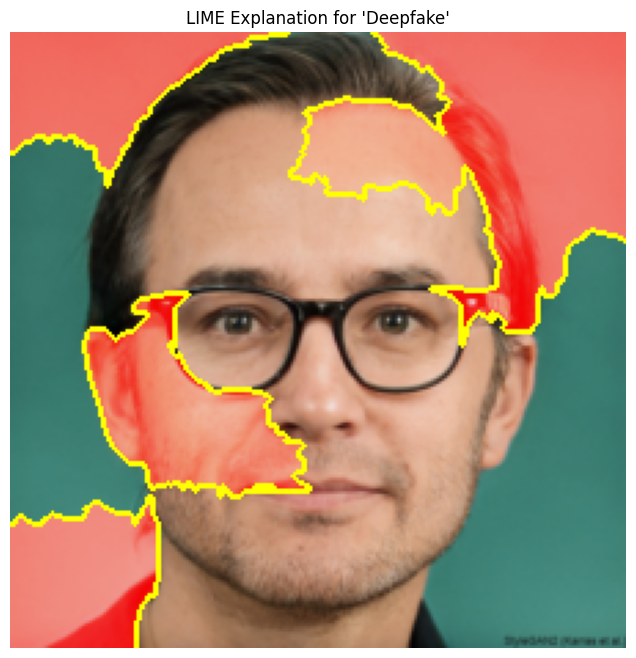

In [72]:
# ================== FULL LIME + ENSEMBLE PIPELINE ==================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from timm import create_model
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from PIL import Image

# ----------------- 0. Set global seed -----------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# ----------------- 1. Ensemble Model -----------------
class EnsembleModel(nn.Module):
    def __init__(self, modelA, modelB):
        super(EnsembleModel, self).__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.classifier = nn.Linear(2, 1)  # Combines outputs of the two models

    def forward(self, x):
        x1 = self.modelA(x)
        x2 = self.modelB(x)
        x = torch.cat((x1, x2), dim=1)
        x = self.classifier(x)
        return x

# ----------------- 2. Batch Prediction Wrapper -----------------
def batch_predict(images_numpy, model, device):
    model.eval()
    images_tensor = torch.tensor(images_numpy).permute(0, 3, 1, 2).to(device).float()
    IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).to(device).view(1, 3, 1, 1)
    IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).to(device).view(1, 3, 1, 1)
    images_tensor = (images_tensor / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    with torch.no_grad():
        outputs = model(images_tensor)
    probabilities = torch.sigmoid(outputs)
    return torch.cat((1 - probabilities, probabilities), dim=1).cpu().numpy()

# ----------------- 3. LIME Explanation -----------------
def generate_lime_explanation(ensemble_model, image_tensor, class_names, device):
    explainer = lime_image.LimeImageExplainer()

    def denormalize(tensor, mean, std):
        mean = torch.tensor(mean).view(3, 1, 1)
        std = torch.tensor(std).view(3, 1, 1)
        return tensor * std + mean

    unnorm_image = denormalize(image_tensor.squeeze().cpu(),
                               [0.485, 0.456, 0.406],
                               [0.229, 0.224, 0.225])
    unnorm_image_np = (unnorm_image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    lime_img = None
    predicted_class = "Unknown"

    try:
        explanation = explainer.explain_instance(
            unnorm_image_np,
            lambda x: batch_predict(x, ensemble_model, device),
            top_labels=1,
            hide_color=0,
            num_samples=3000  # Increased for stability
        )
        temp, mask = explanation.get_image_and_mask(
            explanation.top_labels[0],
            positive_only=False,
            num_features=5,
            hide_rest=False
        )
        lime_img = mark_boundaries(temp / 255.0, mask)
        predicted_class = class_names[explanation.top_labels[0]]

        # ---- Print actual probability for the predicted class ----
        with torch.no_grad():
            output = ensemble_model(image_tensor)
            prob = torch.sigmoid(output).item()
        print(f"Predicted class: {predicted_class}, Probability: {prob:.4f}")

    except Exception as e:
        print(f"❌ LIME explanation failed: {e}")
        lime_img = unnorm_image_np / 255.0

    plt.figure(figsize=(8, 8))
    plt.imshow(lime_img)
    plt.title(f"LIME Explanation for '{predicted_class}'")
    plt.axis('off')
    plt.show()

# ----------------- 4. Load Ensemble Model -----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_densenet = create_model('densenet121', pretrained=False, num_classes=1)
model_efficientnet = create_model('efficientnet_b0', pretrained=False, num_classes=1)
ensemble_model = EnsembleModel(model_densenet, model_efficientnet)

MODEL_PATH = r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\ensemble_results\final_best_model.pth"
if not os.path.exists(MODEL_PATH):
    print(f"❌ Error: Model file not found at '{MODEL_PATH}'")
else:
    state_dict = torch.load(MODEL_PATH, map_location=device)
    ensemble_model.load_state_dict(state_dict, strict=False)
    ensemble_model.to(device).eval()
    print(f"✅ Ensemble model loaded successfully from '{MODEL_PATH}'")

# ----------------- 5. Load Custom Image -----------------
def load_image_from_path(img_path, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(img_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    return tensor

# ----------------- 6. Run Example -----------------
class_names = ["Deepfake", "Real"]

# 👉 Set your own image path here
IMG_PATH = r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\df_face.jpg"

if os.path.exists(IMG_PATH):
    test_image = load_image_from_path(IMG_PATH, device)
    generate_lime_explanation(ensemble_model, test_image, class_names, device)
else:
    print(f"❌ Image not found at {IMG_PATH}")

## GradCAM

✅ Ensemble model loaded from C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\ensemble_results\final_best_model.pth


c:\Users\Shohan\miniconda3\envs\learn\lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


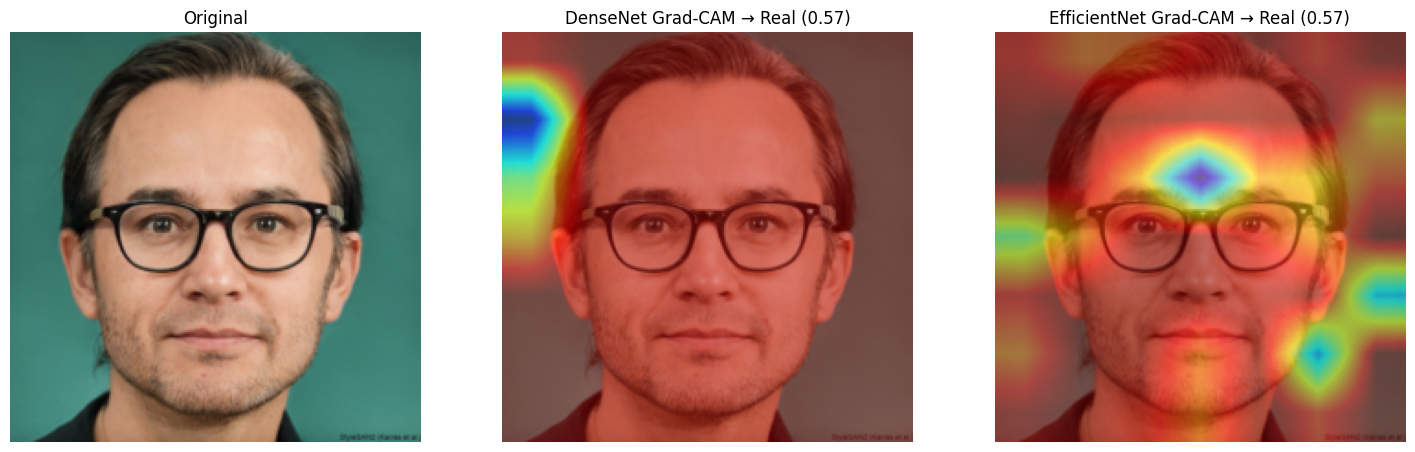

In [73]:
# ================== GRAD-CAM ENSEMBLE (DENSENET + EFFICIENTNET) ==================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from timm import create_model
from torchvision import transforms
from PIL import Image

# ---- Ensemble Model ----
class EnsembleModel(nn.Module):
    def __init__(self, modelA, modelB):
        super(EnsembleModel, self).__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.classifier = nn.Linear(2, 1)

    def forward(self, x):
        x1 = self.modelA(x)
        x2 = self.modelB(x)
        x = torch.cat((x1, x2), dim=1)
        return self.classifier(x)

# ---- GradCAM ----
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hook_handles:
            h.remove()

    def generate(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        loss = output[:, 0]   # binary logit
        loss.backward()

        # GAP on gradients
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (input_tensor.shape[2], input_tensor.shape[3]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# ---- Visualization ----
def visualize_gradcam_dual(ensemble_model, image_tensor, device, class_names=["Deepfake","Real"]):
    cams = {}
    # DenseNet target layer
    target_layer_dn = ensemble_model.modelA.features[-1]
    gradcam_dn = GradCAM(ensemble_model, target_layer_dn)
    cams["DenseNet"] = gradcam_dn.generate(image_tensor.to(device))
    gradcam_dn.remove_hooks()

    # EfficientNet target layer
    target_layer_eff = ensemble_model.modelB.conv_head
    gradcam_eff = GradCAM(ensemble_model, target_layer_eff)
    cams["EfficientNet"] = gradcam_eff.generate(image_tensor.to(device))
    gradcam_eff.remove_hooks()

    # Prediction
    with torch.no_grad():
        logits = ensemble_model(image_tensor.to(device))
        prob = torch.sigmoid(logits).item()
    predicted_class = class_names[int(prob >= 0.5)]

    # De-normalize
    def denormalize(tensor, mean, std):
        mean = torch.tensor(mean).view(3,1,1)
        std = torch.tensor(std).view(3,1,1)
        return tensor * std + mean

    unnorm_img = denormalize(image_tensor.squeeze().cpu(),
                             [0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    unnorm_img = np.clip(unnorm_img.permute(1,2,0).numpy(),0,1)

    # Plot all
    plt.figure(figsize=(18,6))
    plt.subplot(1,3,1)
    plt.imshow(unnorm_img)
    plt.title("Original")
    plt.axis("off")

    for i,(name,cam) in enumerate(cams.items(), start=2):
        heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap)/255
        overlay = heatmap + np.float32(unnorm_img)
        overlay = overlay / np.max(overlay)

        plt.subplot(1,3,i)
        plt.imshow(overlay)
        plt.title(f"{name} Grad-CAM → {predicted_class} ({prob:.2f})")
        plt.axis("off")

    plt.show()

# ---- Load Ensemble Model ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_densenet = create_model("densenet121", pretrained=False, num_classes=1)
model_efficientnet = create_model("efficientnet_b0", pretrained=False, num_classes=1)
ensemble_model = EnsembleModel(model_densenet, model_efficientnet)

MODEL_PATH = r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\ensemble_results\final_best_model.pth"
state_dict = torch.load(MODEL_PATH, map_location=device)
ensemble_model.load_state_dict(state_dict, strict=False)
ensemble_model.to(device).eval()
print(f"✅ Ensemble model loaded from {MODEL_PATH}")

# ---- Load Your Own Image ----
image_path = r"C:\Users\Shohan\Desktop\DeepFakeImg\MyLearning\df_face.jpg"  # <-- CHANGE THIS
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])
img = Image.open(image_path).convert("RGB")
image_tensor = transform(img).unsqueeze(0)

# ---- Run Dual Grad-CAM ----
visualize_gradcam_dual(ensemble_model, image_tensor, device, class_names=["Deepfake","Real"])
